# Executive summary
- Novel method for combining four sets of disjoint tiles with better calibration than each set alone.
- Illustrate with simple example showcasing good performance and solving problems of original tiles (without needed to retrain BLISS).

## Variational Distribution
We parameterize the following variational distribution:
\begin{equation}
  \label{eq:vardist}
  \begin{split}
    A_{i} \sim \mathrm{Bernoulli}(\alpha_{i}) \\
    \ell_{i} \sim \mathcal N_{T_{i}} (\mu_{i}, \Sigma_{i})
  \end{split}
\end{equation}
where subscript $T_{i}$ means trucation to the tile $T_{i}$.
The variational distribution is $q(\{A_{i}, \ell_{i}\}) = \prod_{i=1}^{T} q(A_{i}, \ell_{i})$.
Unlike in the previous, non-overlapping version, we do not assume that each tile $T_i$ is disjoint.

In this formulation, the variational posterior factorizes over tiles:
$$
q(\{A_i, \ell_i\}) = \prod_{i=1}^T \alpha_i^{A_i} q_i^\ell(\ell_i) ^{A_i} (1 - \alpha_i)^{1 - A_i}.
$$

We want to evaluate the probability of a full, "tile-free" catalog $\{\ell_{n}\}$ under the variational distribution.
However, to do so, we need to know the assignment of each object to a tile $A_n$.

Define $A_{i, n}$ as the indicator of the event that object $n$ was generated by $i$, i.e. $A_{i, n} \triangleq 1[\ell_n = \ell_i]$. Then,
$$
A_n \triangleq \sum_{i=1}^T n A_{i, n}
$$

The number of objects that appear in tile $i$ is a sum. From our variational distribution, this is at most equal to one:
$$
  A_{i} = \sum_{n=1}^{N} A_{i, n}.
$$

The location of the object in tile $i$ can also be expressed as a sum, since at most only one $A_{{i, n}}$ is non-zero:
$$
  \ell_{i} = \sum_{n=1}^{N} A_{i, n} \ell_{n}.
$$

Now, we can re-write the density as follows:
$$
  \begin{split}
    \log q(\{\ell_{n}, A_{n}\}) &= \sum_{i=1}^{T} \log q_{i} (\sum_{n=1}^{N} A_{i, n}, \sum_{n=1}^{N} A_{i, n} \ell_{n}) \\
                                &= \sum_{i=1}^{T} (\sum_{n=1}^{N} A_{i, n}) (\log \alpha_{i} + \log q_{i}^{\ell} (\sum_{n=1}^{N} A_{i, n }\ell_{n})) + (1 - \sum_{n=1}^{N} A_{i, n}) \log (1 - \alpha_{i}) \\
    &= \sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n})\right) + (\frac 1 N - A_{i, n}) \log (1 - \alpha_{i}) \\
                                &= \sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n})\right) - A_{i, n} \log (1 - \alpha_{i}) + \frac 1 N \log (1 - \alpha_{i}) \\
                                &= \sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \\
  \end{split}
$$

Next, we want to integrate out $A_n$.
However, in the case of overlapping tiles, there arises some ambiguity.
If two overlapping tiles detect an object, are there two objects, or just one object counted twice?
To resolve this ambiguity, we add an additional condition that two tiles with overlap cannot be both "on"
$$
A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing
$$
As a result of this assumption, there is at most one object in any tile $T_i$. However, with overlap, it could be the case that $T_i$ did not **generate** that object.

Thus, our variational posterior is:
$$
\tilde q (\{\ell_n, A_n\}) = \frac{q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing]}{\int q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing] d \{\ell_n, A_n\}}
$$

where $g(\ell_n)$ is the set of tiles that intersect object $\ell_n$.
The denominator is intractable. The numerator is a lower bound:
$$
q (\{\ell_n, A_n\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing] \le \tilde q (\{\ell_n, A_n\})
$$
As long as the condition $A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing$ is true, $q$ is a lower bound to $\log q$. Since we control the distribution during sleep-phase training, we can guarentee this to be true. One such condition is a **non-overlapping** condition on the locations:
$$
1[\{g(\ell_n) \cap g(\ell_m) = \varnothing\}]
$$
This is stronger than the required condition.

We now integrate out $A_n$ as follows:
$$
\begin{split}
q (\{\ell_n\}) &= \int q (\{\ell_n, A_n\}) d{\{A_n\}} \\
&= \sum_{\{A_n\}} \exp \left (\sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )\\
&= \left(\sum_{\{A_n\}} \prod_{n=1}^{N} \frac{\alpha_{A_n}}{1 - \alpha_{A_n}} q_{A_n}^{\ell} (\ell_{n}) \right) \prod_{i=1}^{T} (1 - \alpha_{i})
\end{split}
$$
Note that this distribution is intractable as it requires integrating over all possible combinations of $A_n$. Hence we utilize another lower bound:

$$
\begin{split}
\log q (\{\ell_n\}) &= \log \left(\sum_{\{A_n\}} \prod_{n=1}^{N} \frac{\alpha_{A_n}}{1 - \alpha_{A_n}} q_{A_n}^{\ell} (\ell_{n}) \right) \log \prod_{i=1}^{T} (1 - \alpha_{i}) \\
&= \log \left(\sum_{\{A_n \in g(\ell_n) \}} \prod_{n=1}^{N} \frac{\alpha_{A_n}}{1 - \alpha_{A_n}} q_{A_n}^{\ell} (\ell_{n}) \right) \log \prod_{i=1}^{T} (1 - \alpha_{i}) \\
&\ge \sum_{\{A_n \in g(\ell_n)\}} \left (\sum_{i=1}^{T} \sum_{n=1}^{N} A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )\\
&= \left (\sum_{n=1}^{N} \sum_{i \in g(\ell_n)}  A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )\\
\end{split}
$$

## FAVI objective
$$
\mathbb E_{P(\{\ell_n\}, X)} \log q (\{\ell_n\}) \ge \mathbb E_{P(\{\ell_n\}, X)} \left (\sum_{n=1}^{N} \sum_{i \in g(\ell_n)}  A_{i, n} \left ( \log \alpha_{i} + \log q_{i}^{\ell} (\ell_{n}) - \log (1 - \alpha_{i}) \right) + \sum_{i=1}^{T} \log (1 - \alpha_{i}) \right )
$$
This is a lower bound to the true FAVI objective for two reasons.
1. First, we do not use the normalized $\tilde q$ accounting for filtering two overlapping tiles being on at the same time.
1. Second, we bring a logarithm inside an expectation for tractability.

# Notes
- In our variational distribution, $\alpha_{i}$ is the probability that an object was generated by tile $i$ given that no other tiles placed an object in the vicinity of tile $i$.

$$
P(A_i | A_{neighbor(i)} = 0) \propto P(A_i, A_{neighbor(i)} = 0) \propto \alpha_i^{A_i} (1 - \alpha_i)^{1 - A_i} \prod_j (1 - \alpha_j) \propto \alpha_i^{A_i} (1 - \alpha_i)^{1 - A_i}.
$$


- Suppose we split the image into four disjoint sets of tiles. Each location will touch one tile from each set, so we can split up the objective this way. We recover the original, non-overlapping tile objective (but amortized across tile placement).

# Inference
We need to infer the marginal probability of $P(A_i)$; the current output is the probability of $A_i$ given no other overlapping tiles.

This can be accomplished with a simple MCMC algorithm, where $P(A_i = 1 | A_{overlap(i)}) = 0$ if any overlapping tiles are present and $\alpha_i$ otherwise.

## Algorithm
1. Start at $A_i = 0$ everywhere.
1. For each iteration...
  1. For each layer of disjoint tiles $k$
    1. For each tile $A_{i, k}$ (parallelizable)
      1. Evaluate whether any tiles overlapping with $A_{i, k}$ are on.
      1. Sample $A_{i, k} = 1$ with probability $\alpha_i 1[A_{overlap(i) = 0}]$.

# Simple example
Consider original tiles + one overlapping layer where both height and width are shifted by 2 pixels.

In [6]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
from einops import rearrange, repeat, reduce
import torch

from case_studies.sdss_galaxies_vae.reconstruction import load_models, reconstruct_scene_at_coordinates

In [7]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [21]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config")   

In [22]:
simulated_dataset = instantiate(cfg.datasets.simulated)

In [49]:
batch_size=1
n_tiles_h=5
n_tiles_w=5
# tile_catalog = simulated_dataset.sample_prior(batch_size, n_tiles_h, n_tiles_w)
# tc2 = torch.load("catalog_with_stuff.pt")
# for (h, w) in ((0, 4), (3, 1)):
#     tile_catalog.n_sources[0, h, w] = 1
#     tile_catalog.locs[0, h, w] = tc2.locs[0, h, w]
#     for k, v in tc2.items():
#         tile_catalog[k][0, h, w] = v[0, h, w]
# torch.save(tile_catalog, "catalog.pt")
tile_catalog = torch.load("catalog.pt")

In [50]:
img, bg = simulated_dataset.simulate_image_from_catalog(tile_catalog)

In [51]:
import matplotlib.pyplot as plt

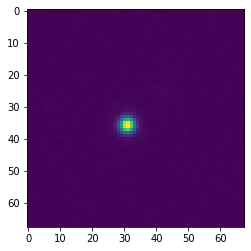

In [52]:
%matplotlib inline
plt.imshow(img[0, 0])

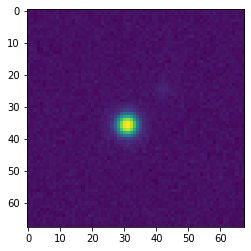

In [53]:
plt.imshow(img[0, 0].log())

In [54]:
tile_catalog["galaxy_params"].shape

torch.Size([1, 5, 5, 1, 7])

In [60]:
tile_catalog.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 1, 0, 0]]])

In [56]:
# load bliss
device = torch.device(cfg.reconstruct.device)
decoder, encoder, _ = load_models(cfg, device)
bp = 24
h, w = img.shape[2], img.shape[3]
# img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h-bp), (bp, w-bp))
img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 88.99it/s]


In [57]:
tile_map_recon.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0]]], device='cuda:0')

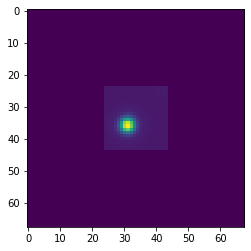

In [58]:
plt.imshow(torch.nn.functional.pad(img_recon[0, 0], (bp, bp, bp, bp)))

In [61]:
tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[9.3481e-03, 1.2611e-03, 3.4596e-04, 5.5634e-04, 9.6403e-01],
        [3.9811e-03, 3.6433e-03, 1.8099e-03, 1.0282e-03, 2.8307e-03],
        [4.5249e-03, 6.6735e-02, 1.4471e-02, 3.1055e-03, 3.8651e-04],
        [7.3943e-04, 9.7564e-01, 9.0430e-04, 1.4140e-02, 1.2972e-04],
        [1.3235e-03, 3.6877e-03, 2.1079e-02, 1.7208e-03, 3.5890e-04]],
       device='cuda:0')

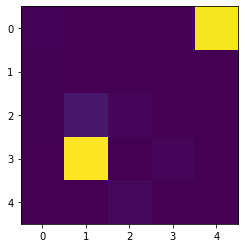

In [62]:
plt.imshow(tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

In [63]:
tile_map_recon.locs[0, 3, 1, 0]

tensor([0.0504, 0.8309], device='cuda:0')

In [64]:
tile_catalog.locs[0, 3, 1, 0]

tensor([0.0322, 0.8106])

In [65]:
tile_catalog2 = tile_catalog.copy()
tile_catalog2.locs = tile_catalog.locs.clone()
tile_catalog2.locs[0, 3, 1, 0] = 0.999

In [66]:
img2, bg2 = simulated_dataset.simulate_image_from_catalog(tile_catalog2)

In [67]:
img_recon2, tile_map_recon2 = reconstruct_scene_at_coordinates(encoder, decoder, img2, bg2, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 82.61it/s]


In [68]:
tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[8.2986e-05, 1.1679e-04, 1.3198e-04, 1.6114e-04, 9.8404e-01],
        [2.7422e-03, 1.9424e-03, 3.9836e-04, 7.5624e-04, 1.7739e-03],
        [2.8499e-03, 4.0644e-03, 3.0893e-03, 2.5216e-03, 1.2014e-03],
        [2.3755e-03, 1.3444e-01, 1.7783e-01, 7.4886e-03, 1.7285e-04],
        [9.3516e-04, 1.3331e-01, 9.0787e-02, 7.8805e-03, 9.5556e-05]],
       device='cuda:0')

In [69]:
tile_map_recon2["n_source_log_probs"][0, 3:5, 1:3, 0, 0].exp().sum()

tensor(0.5364, device='cuda:0')

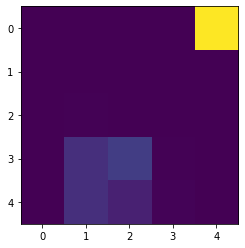

In [70]:
plt.imshow(tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

# Overlapping procedure
First, we shift the input image by two pixels in each direction and feed each to the encoder separately.

In [90]:
def make_imgs_and_bgs():
    imgs = []
    bgs = []
    for w in (0, 2):
        for h in (0, 2):
            img_shifted = torch.zeros_like(img2)
            img_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)] = img2[:, :, h:, w:]
            bg_shifted = torch.zeros_like(bg2)
            bg_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)]  = bg2[:, :, h:, w:]
            if h > 0:
                img_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
                bg_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
            if w > 0:
                img_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
                bg_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
            if (h > 0) and (w > 0):
                img_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
                bg_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
            imgs.append(img_shifted)
            bgs.append(bg_shifted)
    return imgs, bgs
imgs, bgs = make_imgs_and_bgs()

In [91]:
tile_maps = []
for img, bg in zip(imgs, bgs):
    _, tile_map_shifted = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))
    tile_maps.append(tile_map_shifted)

Encoding ptiles: 1it [00:00, 37.57it/s]
Encoding ptiles: 1it [00:00, 102.77it/s]
Encoding ptiles: 1it [00:00, 104.46it/s]
Encoding ptiles: 1it [00:00, 104.32it/s]


In [74]:
log_probs_all = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)

For each tile, the estimated probability is not the marginal probability that the tile generated an object. Rather, the probability is conditioned on no other overlapping tiles generating an object. We utilize a simple MCMC algorithm to estimate the marginal probability for each tile.

In [92]:
def has_no_neighbor_all_four(idx, tiles, offsets):
    no_neighbors = torch.ones_like(tiles[:, :, idx])
    own_offset = offsets[idx]
    for other, (offset_h, offset_w) in enumerate(offsets):
        if other != idx:
            offset_h = offset_h - own_offset[0]
            offset_w = offset_w - own_offset[1]
            n = has_no_neighbor(offset_h, offset_w, tiles[:, :, other], prior_effect=1.00)
            #print(n)
            no_neighbors *= n
    #print(no_neighbors)
    return no_neighbors

In [93]:
def sample_tile_marginals_from_cats(tile_maps, offsets, n_iter=200):
    log_probs = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)
    tiles = torch.zeros_like(log_probs)
    tile_sum = torch.zeros_like(log_probs)
    for _ in range(n_iter):
        for idx, offset in enumerate(offsets):
            no_neighbors = has_no_neighbor_all_four(idx, tiles, offsets)
            #print(no_neighbors)
            tiles[:, :, idx] = torch.rand_like(tiles[:, :, idx]).log() <= (log_probs[:, :, idx] + no_neighbors.log())
            #print(tiles[:, :, idx])
        tile_sum += tiles
    return tile_sum / n_iter

In [94]:
xx_offsets = [
    (0,0),
    (1,0),
    (0,1),
    (1,1),
]
#xx = calc_tile_marginals_from_cats([tile_maps[0], tile_maps[3]], [xx_offsets[0], xx_offsets[3]], n_iter=200)
xx = sample_tile_marginals_from_cats(tile_maps, xx_offsets, n_iter=1_000)

In [96]:
xx.shape

torch.Size([5, 5, 4])

In [97]:
xx.shape

torch.Size([5, 5, 4])

In [98]:
xx[:,:, 0]

tensor([[0.0010, 0.0000, 0.0000, 0.0000, 0.7400],
        [0.0010, 0.0030, 0.0000, 0.0000, 0.0040],
        [0.0020, 0.0020, 0.0040, 0.0010, 0.0010],
        [0.0010, 0.0000, 0.0020, 0.0100, 0.0000],
        [0.0000, 0.0010, 0.0010, 0.0040, 0.0000]], device='cuda:0')

In [99]:
xx[:,:, 1]

tensor([[0.0010, 0.0020, 0.0000, 0.0020, 0.0020],
        [0.0010, 0.0040, 0.0000, 0.0010, 0.0010],
        [0.0010, 0.0060, 0.0060, 0.0070, 0.0000],
        [0.0010, 0.0060, 0.0020, 0.0010, 0.0010],
        [0.0000, 0.0010, 0.0020, 0.0030, 0.0020]], device='cuda:0')

In [100]:
xx[:,:, 2]

tensor([[0.0010, 0.0020, 0.0010, 0.0030, 0.2450],
        [0.0030, 0.0010, 0.0020, 0.0030, 0.0050],
        [0.0020, 0.0020, 0.0030, 0.0000, 0.0010],
        [0.0020, 0.0000, 0.0090, 0.0020, 0.0010],
        [0.0000, 0.0010, 0.0000, 0.0050, 0.0000]], device='cuda:0')

In [103]:
xx[:,:, 3]

tensor([[0.0020, 0.0020, 0.0050, 0.0000, 0.0000],
        [0.0000, 0.0010, 0.0030, 0.0010, 0.0030],
        [0.0010, 0.0060, 0.0080, 0.0020, 0.0000],
        [0.0020, 0.9900, 0.0000, 0.0000, 0.0000],
        [0.0020, 0.0000, 0.0050, 0.0000, 0.0000]], device='cuda:0')

In [104]:
0.9640 + 0.0050 + 0.0340

1.003

In [105]:
log_probs_all[:, :, 3].exp()

tensor([[8.1724e-04, 1.9298e-03, 4.4093e-03, 3.2770e-03, 8.2417e-02],
        [1.6574e-03, 8.5347e-04, 1.8072e-03, 9.2162e-04, 1.1022e-03],
        [2.3829e-03, 5.3508e-03, 6.8630e-03, 1.4640e-03, 7.3523e-04],
        [1.3471e-03, 9.9967e-01, 1.6547e-04, 2.5001e-03, 1.5060e-04],
        [1.3331e-03, 1.5209e-04, 7.2192e-03, 9.7096e-04, 2.1818e-04]],
       device='cuda:0')

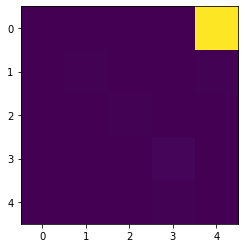

In [106]:
plt.imshow(xx[:,:, 0].cpu())

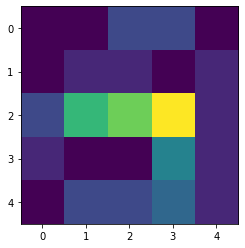

In [668]:
plt.imshow(xx[:,:, 1].cpu())

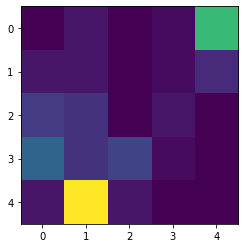

In [669]:
plt.imshow(xx[:,:, 2].cpu())

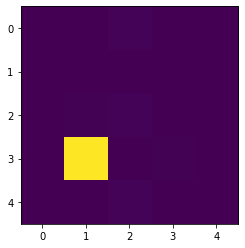

In [670]:
plt.imshow(xx[:,:, 3].cpu())

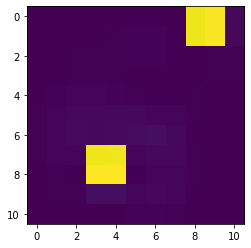

In [671]:
xx_dbl = repeat(xx, "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu() / 4
xx_super = torch.zeros(xx_dbl.shape[0] + 1, xx_dbl.shape[1] + 1)

xx_super[:-1, :-1] += xx_dbl[:, :, 0]
xx_super[1:, :-1] += xx_dbl[:, :, 1]
xx_super[:-1, 1:] += xx_dbl[:, :, 2]
xx_super[1:, 1:] += xx_dbl[:, :, 3]

plt.imshow(xx_super)

New estimate of number of objects in area

In [675]:
xx.sum()

tensor(2.1920, device='cuda:0')

Each individual estimate

In [676]:
reduce(log_probs_all.exp(), "nth ntw d -> d", "sum")

tensor([1.5593, 0.8112, 1.9235, 1.0747], device='cuda:0')

In [684]:
log_probs_all[:, :, 2].exp()

tensor([[1.5723e-04, 6.2463e-04, 4.0061e-04, 5.0028e-02, 7.6829e-01],
        [3.9203e-03, 1.1829e-03, 7.9838e-04, 3.8924e-03, 1.9925e-03],
        [5.0563e-03, 2.4661e-03, 2.7251e-03, 1.3223e-03, 7.8273e-04],
        [6.3221e-03, 1.6886e-01, 6.6549e-03, 1.8813e-03, 1.8542e-04],
        [1.5403e-03, 8.9064e-01, 4.3599e-04, 3.0496e-03, 2.6265e-04]],
       device='cuda:0')

The third set of disjoint tiles only happens to be close to the true because it under-estimates the object to the upper-right and over-estimates the object to the bottom-left.

In [677]:
log_probs_all.exp().sum() / 4

tensor(1.3422, device='cuda:0')

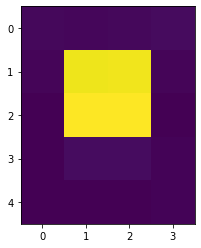

In [678]:
plt.imshow(xx_super[6:, 2:6])

In [679]:
xx_super[6:, 2:6].sum()

tensor(1.0467)